# Analisi rapporto studenti-studio

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print(f'Pandas:     {pd.__version__}')
print(f'Numpy:      {np.__version__}')
print(f'Matplotlib: {plt.matplotlib.__version__}')

Pandas:     3.0.1
Numpy:      2.4.3
Matplotlib: 3.10.8


In [4]:
df = pd.read_csv('studenti_studio.csv')
print(df.info())
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   metodo_studio  200 non-null    str    
 1   rendimento     200 non-null    str    
 2   ore_studio     200 non-null    float64
 3   dispositivo    200 non-null    str    
 4   sesso          200 non-null    str    
dtypes: float64(1), str(4)
memory usage: 7.9 KB
None


,ore_studio
count,200.000000
mean,7.854500
std,2.964426
min,1.000000
25%,5.875000
50%,7.850000
75%,9.625000
max,15.800000


In [5]:
df.head(10)

,metodo_studio,rendimento,ore_studio,dispositivo,sesso
0,Libro,Alto,9.3,PC,F
1,Video,Alto,9.6,Tablet,M
2,Gruppo,Medio,8.8,Tablet,M
3,Libro,Medio,3.8,Smartphone,F
4,Appunti,Basso,1.1,Smartphone,F
5,Gruppo,Basso,8.2,PC,M
6,Libro,Medio,6.6,Tablet,F
7,Libro,Alto,9.4,Tablet,F
8,Appunti,Basso,10.1,PC,F
9,Video,Medio,8.4,PC,F


In [6]:
df.tail()

,metodo_studio,rendimento,ore_studio,dispositivo,sesso
195,Appunti,Medio,4.5,PC,F
196,Video,Alto,7.1,PC,M
197,Gruppo,Basso,4.8,Tablet,F
198,Appunti,Medio,10.1,PC,M
199,Appunti,Medio,14.0,Tablet,F


## Analisi dati

In [12]:
print("Distribuzioni")
freq_metodo_studio = df['metodo_studio'].value_counts()
freq_metodo_studio_perc = df['metodo_studio'].value_counts(normalize=True).mul(100).round(1)
print('Metodo di studio')
print("Frequenze assolute")
print(freq_metodo_studio)
print("Frequenze normalizzate")
print(freq_metodo_studio_perc)
freq_metodo_studio
freq_rendimento = df['rendimento'].value_counts()
freq_rendimento_perc = df['rendimento'].value_counts(normalize=True).mul(100).round(1)
freq_rendimento

Distribuzioni
Metodo di studio
Frequenze assolute
metodo_studio
Appunti    71
Video      58
Libro      46
Gruppo     25
Name: count, dtype: int64
Frequenze normalizzate
metodo_studio
Appunti    35.5
Video      29.0
Libro      23.0
Gruppo     12.5
Name: proportion, dtype: float64


rendimento
Medio    84
Alto     69
Basso    47
Name: count, dtype: int64

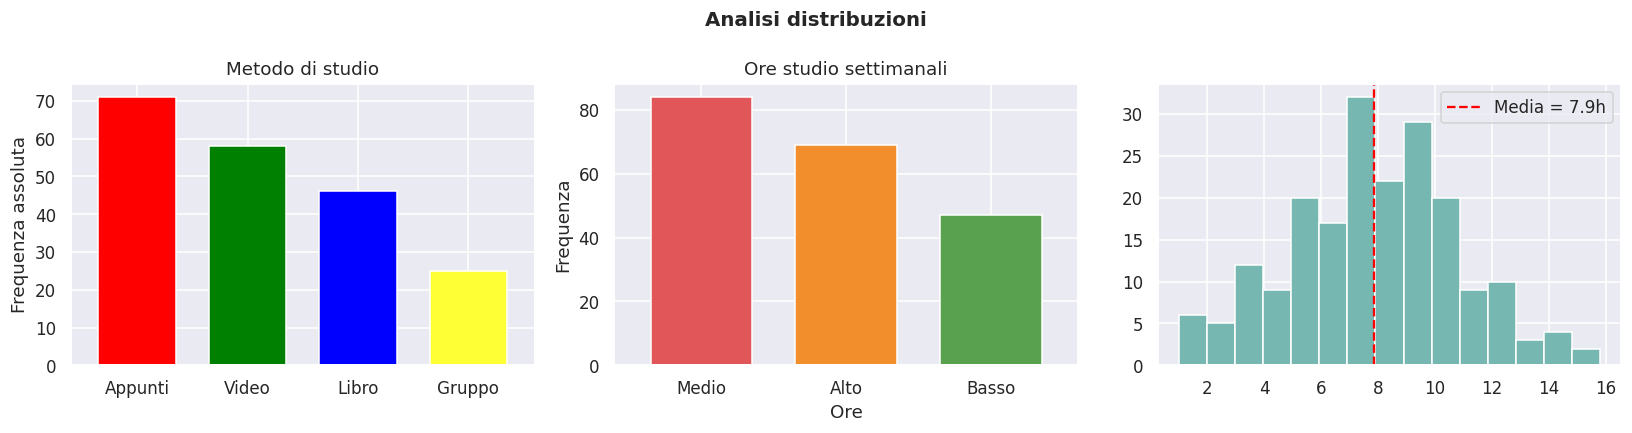

In [22]:
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'monospace'
sns.set_theme(style='darkgrid', palette='muted')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Analisi distribuzioni', fontsize=13, fontweight='bold')

colori = ['red', 'green', 'blue', '#ffff35']
freq_metodo_studio.plot(
    kind='bar', ax=axes[0], color=colori, edgecolor='white', width=0.7
)
axes[0].set_title('Metodo di studio')
axes[0].set_xlabel('')
axes[0].set_ylabel('Frequenza assoluta')
axes[0].tick_params(axis='x', rotation=0)


colori2 = ['#e15759', '#f28e2b', '#59a14f']
freq_rendimento.plot(
    kind='bar', ax=axes[1], color=colori2, edgecolor='white', width=0.7
)
axes[1].set_title('Rendimento')
axes[1].set_xlabel('')
axes[1].set_ylabel('Frequenza assoluta')
axes[1].tick_params(axis='x', rotation=0)

axes[2].hist(df['ore_studio'], bins=15, color='#76b7b2', edgecolor='white')
axes[2].axvline(df['ore_studio'].mean(), color='red', linestyle='--', label=f'Media = {df['ore_studio'].mean():.1f}h')
axes[1].set_title('Ore studio settimanali')
axes[1].set_xlabel('Ore')
axes[1].set_ylabel('Frequenza')
axes[2].legend()

plt.tight_layout()
plt.show()

In [23]:
## Tabelle di contingenza

In [25]:
tab_obs = pd.crosstab(
    df['metodo_studio'],
    df['rendimento'],
    margins=True,
    margins_name='Totale'
)
tab_obs

rendimento,Alto,Basso,Medio,Totale
metodo_studio,,,,
Appunti,23,15,33,71
Gruppo,4,11,10,25
Libro,24,4,18,46
Video,18,17,23,58
Totale,69,47,84,200


In [26]:
tab_pct_riga = pd.crosstab(
    df['metodo_studio'],
    df['rendimento'],
    normalize='index'
).mul(100).round(1)

tab_pct_riga

rendimento,Alto,Basso,Medio
metodo_studio,,,
Appunti,32.4,21.1,46.5
Gruppo,16.0,44.0,40.0
Libro,52.2,8.7,39.1
Video,31.0,29.3,39.7


In [27]:
tab_raw = pd.crosstab(
    df['metodo_studio'],
    df['rendimento'])
tab_raw

rendimento,Alto,Basso,Medio
metodo_studio,,,
Appunti,23,15,33
Gruppo,4,11,10
Libro,24,4,18
Video,18,17,23


## Calcolo delle frequenze attese
Formula = e_ij = (totale_riga_i * totale_colonna_j) / N

In [32]:
N = tab_raw.values.sum()
totali_riga = tab_raw.sum(axis=1)
totali_colonna = tab_raw.sum(axis=0)

# Prodotto dei totali
freq_attese = np.outer(totali_riga.values, totali_colonna.values) / N
tab_freq_attese = pd.DataFrame(freq_attese, index=tab_raw.index, columns=tab_raw.columns)
tab_freq_attese

rendimento,Alto,Basso,Medio
metodo_studio,,,
Appunti,24.495,16.685,29.82
Gruppo,8.625,5.875,10.50
Libro,15.870,10.810,19.32
Video,20.010,13.630,24.36
